# E2.1 – Client Embeddings for Banking Risk Assessment

In this notebook we build the **first of three foundational models (FMFDs)** described in the
*Decoding Risk: Transforming Banks with Customer Embeddings* project.

Instead of moving dozens of raw fields between bank systems, we encode each customer's full
financial profile into a single dense vector (embedding). Downstream models consume that compact
vector, making the whole architecture simpler, faster, and easier to maintain.

**What we do here:**
1. Generate a synthetic dataset of 500 bank customers
2. Convert each customer's structured data into a natural-language description
3. Encode those descriptions with a sentence-transformer model
4. Persist the embeddings for use in Notebook 3
5. Visualise the embedding space with UMAP
6. Run a cosine-similarity search to find customers with similar risk profiles

> **Note:** We use `sentence-transformers/all-MiniLM-L6-v2` as a lightweight stand-in.
> In production you would fine-tune a domain-specific model (e.g. FinGPT) on your own data.

---
**Author:** Adebanji Oluwatimileyin Adelowo  
**GitHub:** [adebanjiadelowo](https://github.com/adebanjiadelowo)

In [1]:
!pip install -q sentence-transformers pandas numpy scikit-learn umap-learn matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import umap

random.seed(42)
np.random.seed(42)

## 1 – Synthetic customer data

A real bank would pull these fields from its core-banking system, CRM, credit bureau feeds, etc.
For this proof-of-concept we generate them randomly.

In [3]:
def generate_customer_data(n=500):
    employment_types = ['Employed', 'Self-employed', 'Retired', 'Unemployed']

    df = pd.DataFrame({
        'customer_id':       ['CUST_{:04d}'.format(i) for i in range(n)],
        'age':               np.random.randint(22, 70, n),
        'annual_income':     np.random.randint(20_000, 200_000, n),
        'credit_score':      np.random.randint(300, 850, n),
        'account_balance':   np.random.randint(500, 100_000, n),
        'num_credit_cards':  np.random.randint(0, 8, n),
        'employment_years':  np.random.randint(0, 40, n),
        'employment_type':   np.random.choice(employment_types, n),
        'num_prev_loans':    np.random.randint(0, 10, n),
        'previous_default':  np.random.choice([0, 0, 0, 1], n),
        'monthly_expenses':  np.random.randint(500, 8_000, n),
        'num_dependents':    np.random.randint(0, 5, n),
    })

    df['debt_to_income'] = (df['monthly_expenses'] * 12 / df['annual_income']).round(2)
    return df


customers_df = generate_customer_data(500)
print('Dataset shape:', customers_df.shape)
customers_df.head()

Dataset shape: (500, 13)


,customer_id,age,annual_income,credit_score,account_balance,num_credit_cards,employment_years,employment_type,num_prev_loans,previous_default,monthly_expenses,num_dependents,debt_to_income
0,CUST_0000,60,155683,438,60961,3,25,Employed,5,0,4349,4,0.34
1,CUST_0001,50,47663,810,75918,2,3,Unemployed,9,1,4668,1,1.18
2,CUST_0002,36,71991,558,67172,2,33,Self-employed,2,1,5076,3,0.85
3,CUST_0003,64,124182,309,35332,4,17,Self-employed,1,1,5155,1,0.50
4,CUST_0004,29,182049,560,32466,4,39,Retired,5,0,7993,4,0.53


## 2 – Convert structured data to natural language

Sentence transformers are trained on text, so we serialise each customer record as a short
paragraph.  This is the key design choice: it lets us incorporate *any* data source (text notes,
transaction descriptions, bureau comments) simply by appending it to the prompt.

In [4]:
def credit_label(score):
    if score < 580:  return 'Very Poor'
    if score < 670:  return 'Fair'
    if score < 740:  return 'Good'
    if score < 800:  return 'Very Good'
    return 'Exceptional'


def customer_to_text(row):
    default_note = (
        'Has a previous default on record.'
        if row['previous_default'] == 1
        else 'No previous defaults.'
    )
    parts = [
        'Customer profile: {}-year-old {}.'.format(int(row['age']), row['employment_type'].lower()),
        'Annual income: ${:,}.'.format(int(row['annual_income'])),
        'Credit score: {} ({}).'.format(int(row['credit_score']), credit_label(int(row['credit_score']))),
        'Account balance: ${:,}.'.format(int(row['account_balance'])),
        'Credit cards held: {}.'.format(int(row['num_credit_cards'])),
        'Employment duration: {} years.'.format(int(row['employment_years'])),
        'Previous loans taken: {}.'.format(int(row['num_prev_loans'])),
        default_note,
        'Monthly expenses: ${:,}.'.format(int(row['monthly_expenses'])),
        'Dependents: {}.'.format(int(row['num_dependents'])),
        'Debt-to-income ratio: {:.2f}.'.format(float(row['debt_to_income'])),
    ]
    return ' '.join(parts)


customers_df['text'] = customers_df.apply(customer_to_text, axis=1)

# Inspect one example
print(customers_df['text'].iloc[0])

Customer profile: 60-year-old employed. Annual income: $155,683. Credit score: 438 (Very Poor). Account balance: $60,961. Credit cards held: 3. Employment duration: 25 years. Previous loans taken: 5. No previous defaults. Monthly expenses: $4,349. Dependents: 4. Debt-to-income ratio: 0.34.


## 3 – Generate embeddings

Each 384-dimensional vector will stand in for an entire customer record throughout the rest
of the system.

In [5]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print('Generating client embeddings ...')
client_embeddings = model.encode(
    customers_df['text'].tolist(),
    show_progress_bar=True,
    batch_size=64,
)

print('\nEmbedding matrix shape:', client_embeddings.shape)

W0502 19:04:59.882000 84845 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating client embeddings ...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


Embedding matrix shape: (500, 384)


## 4 – Persist embeddings

We save a dictionary that pairs each embedding with its customer ID and the original structured
metadata.  Notebook 3 will load this file to build training data for the risk-decision model.

In [6]:
payload = {
    'embeddings':   client_embeddings,
    'customer_ids': customers_df['customer_id'].tolist(),
    'metadata':     customers_df.drop(columns=['text']).to_dict('records'),
}

with open('client_embeddings.pkl', 'wb') as f:
    pickle.dump(payload, f)

print('Saved client_embeddings.pkl')
print('  Customers :', len(payload['customer_ids']))
print('  Embedding dim:', client_embeddings.shape[1])

Saved client_embeddings.pkl
  Customers : 500
  Embedding dim: 384


## 5 – Visualise with UMAP

UMAP projects 384 dimensions down to 2 so we can see whether the embedding space captures
meaningful financial structure.

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


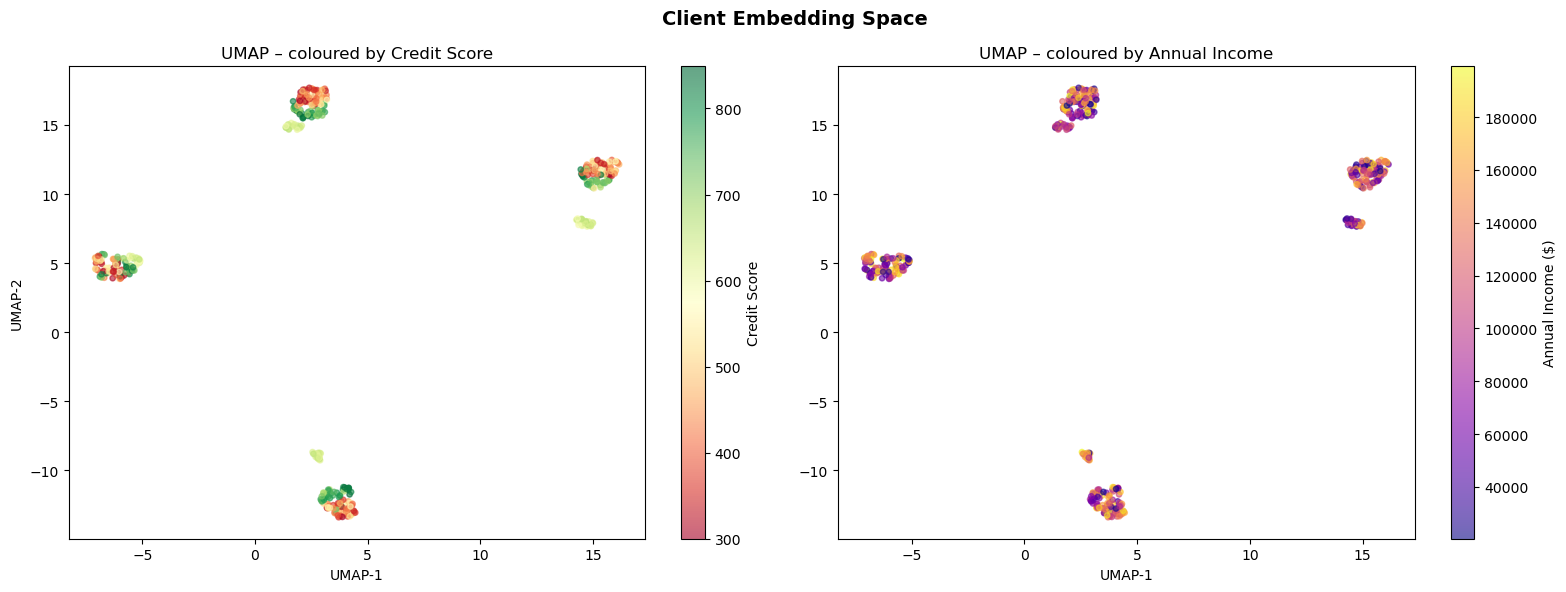

In [7]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords = reducer.fit_transform(client_embeddings)

customers_df['umap_x'] = coords[:, 0]
customers_df['umap_y'] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(
    customers_df['umap_x'], customers_df['umap_y'],
    c=customers_df['credit_score'], cmap='RdYlGn', alpha=0.6, s=15
)
plt.colorbar(sc1, ax=axes[0], label='Credit Score')
axes[0].set_title('UMAP – coloured by Credit Score')
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

sc2 = axes[1].scatter(
    customers_df['umap_x'], customers_df['umap_y'],
    c=customers_df['annual_income'], cmap='plasma', alpha=0.6, s=15
)
plt.colorbar(sc2, ax=axes[1], label='Annual Income ($)')
axes[1].set_title('UMAP – coloured by Annual Income')
axes[1].set_xlabel('UMAP-1')

plt.suptitle('Client Embedding Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('client_embeddings_umap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 – Similarity search

One immediate benefit of the embedding approach: we can find customers with similar overall
profiles using a single cosine-similarity computation – no complex SQL joins required.

In [8]:
def find_similar_customers(query_idx, embeddings, df, top_k=5):
    query_vec = embeddings[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, embeddings)[0]
    sims[query_idx] = -1  # exclude self
    top_idx = np.argsort(sims)[-top_k:][::-1]

    q = df.iloc[query_idx]
    print('=== Query customer ===')
    print('ID: {}  |  Age: {}  |  Income: ${:,}  |  Credit score: {}  |  Default: {}'.format(
        q['customer_id'], int(q['age']), int(q['annual_income']),
        int(q['credit_score']), int(q['previous_default'])))

    print('\n=== Top {} similar customers ==='.format(top_k))
    print('-' * 85)
    for rank, idx in enumerate(top_idx, 1):
        c = df.iloc[idx]
        print('{}. {}  Age: {}  Income: ${:,}  Credit: {}  Default: {}  Similarity: {:.4f}'.format(
            rank, c['customer_id'], int(c['age']), int(c['annual_income']),
            int(c['credit_score']), int(c['previous_default']), sims[idx]))


# Try a few different query customers
for query in [0, 42, 100]:
    find_similar_customers(query, client_embeddings, customers_df, top_k=3)
    print()

=== Query customer ===
ID: CUST_0000  |  Age: 60  |  Income: $155,683  |  Credit score: 438  |  Default: 0

=== Top 3 similar customers ===
-------------------------------------------------------------------------------------
1. CUST_0386  Age: 60  Income: $155,504  Credit: 676  Default: 0  Similarity: 0.9933
2. CUST_0251  Age: 61  Income: $38,017  Credit: 340  Default: 0  Similarity: 0.9915
3. CUST_0459  Age: 60  Income: $92,303  Credit: 336  Default: 0  Similarity: 0.9902

=== Query customer ===
ID: CUST_0042  |  Age: 39  |  Income: $58,513  |  Credit score: 442  |  Default: 1

=== Top 3 similar customers ===
-------------------------------------------------------------------------------------
1. CUST_0300  Age: 39  Income: $57,626  Credit: 341  Default: 0  Similarity: 0.9946
2. CUST_0113  Age: 49  Income: $58,102  Credit: 300  Default: 1  Similarity: 0.9936
3. CUST_0461  Age: 43  Income: $96,125  Credit: 413  Default: 0  Similarity: 0.9932

=== Query customer ===
ID: CUST_0100  |  A

## Summary

We now have a 384-dimensional embedding for each of our 500 synthetic customers, persisted in
`client_embeddings.pkl`.

**Next step →** [E2_2_Product_Embeddings.ipynb](E2_2_Product_Embeddings.ipynb) builds the
equivalent embeddings for financial products and individual loan transactions.